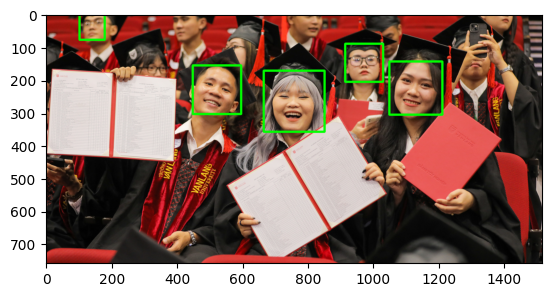

In [11]:
import cv2
import matplotlib.pyplot as vu
img = cv2.imread("/content/Picture1.png")
img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
# dots that would look like STOP signs
stop_data = cv2.CascadeClassifier('/content/haarcascade_frontalface_default.xml') #('/content/haarcascade_frontalcatface.xml')
found = stop_data.detectMultiScale(img_gray,minSize =(20, 20))
amount_found = len(found)

if amount_found != 0:
 for (x, y, width, height) in found:
    cv2.rectangle(img_rgb, (x, y),
    (x + height, y + width),
    (0, 255, 0), 5)
vu.imshow(img_rgb)

2

(np.float64(-0.5), np.float64(1351.5), np.float64(1443.5), np.float64(-0.5))

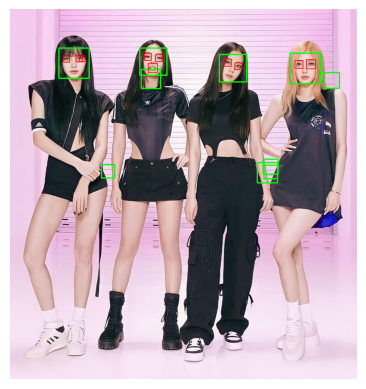

In [12]:
import cv2
import matplotlib.pyplot as vu

img = cv2.imread("/content/1.jpg")
img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# face
face_data = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')

# thêm các đặc trưng
eye_data = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_eye.xml')
smile_data = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_smile.xml')

found = face_data.detectMultiScale(img_gray, minSize=(20, 20))
amount_found = len(found)

if amount_found != 0:
    for (x, y, width, height) in found:
        cv2.rectangle(img_rgb, (x, y),
                      (x + width, y + height),
                      (0, 255, 0), 3)

        roi_gray = img_gray[y:y+height, x:x+width]
        roi_color = img_rgb[y:y+height, x:x+width]

        # detect mắt
        eyes = eye_data.detectMultiScale(roi_gray)
        for (ex, ey, ew, eh) in eyes:
            cv2.rectangle(roi_color, (ex, ey),
                          (ex + ew, ey + eh),
                          (255, 0, 0), 2)

        # detect miệng / nụ cười
        smiles = smile_data.detectMultiScale(roi_gray, 1.8, 20)
        for (sx, sy, sw, sh) in smiles:
            cv2.rectangle(roi_color, (sx, sy),
                          (sx + sw, sy + sh),
                          (0, 0, 255), 2)

vu.imshow(img_rgb)
vu.axis("off")